# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)


plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
users.isna().sum()
users.isna().mean() * 100

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64

In [ ]:
# cantidad de nulos para usage
usage.isna().sum()
usage.isna().mean() * 100

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Users tiene la columna churn_data tiene 92.4% de nulos normal, no hay fecha de cese de la llamada, se puede mantener o eliminar.
- en Usage las columnas duration 55.190 y length 44.740 cantidad de valores que afectaría cualquier resultado revisaría para imputarlos o dejarlos como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
#columnas numéricas : user_id, age
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` ... No se analiza porque es un identificador y debe ser unico para cada usuario
- La columna `age` la edades estan entre 18 y 75 años que es una poblacion normal

In [ ]:
# explorar columnas numéricas de usage
#columnas numéricas : user_id, age
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [ ]:
# explorar columnas categóricas de users
users = users.rename(columns={'tariff': 'plan'})
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` de 500 datos, hay 76 ciudades únicas, la que más se presenta es Москва, que aparece 99 vrces.
- La columna `plan` Tiene 2 valores únicos, tiene mayor frecuencia smart que se repite 351 veces-

In [ ]:
# explorar columna categórica de usage
columnas_usage = ['type']
usage[columnas_usage].describe()

,type
count,40000
unique,2
top,text
freq,22092


La columna type: de 40000 datos hay 2 valores unicos, el que más se repite es text con 22.092 repeticiones.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- No encontré sentinels clásicos (–999, 999, 0, –1), pero sí una columna con un comportamiento especial que es churt_date porque pueden ser usuarios que no se han salido de los planes, luego los mantendría.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
if "reg_date" in users.columns:
    users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce", utc=True)
else:
    users["reg_date"] = pd.NaT

print(users['reg_date'].dtype)
users['reg_date'].head()
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

datetime64[ns, UTC]


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [ ]:
# Convertir a fecha la columna `date` de usage
if "date" in usage.columns:
    usage["date"] = pd.to_datetime(usage["date"], errors="coerce", utc=True)
else:
    usage["date"] = pd.NaT

print(usage['date'].dtype)
usage['date'].head()
# Revisar los años presentes en `reg_date` de users
usage['date'].dt.year.value_counts().sort_index()

datetime64[ns, UTC]


2024.0    39950
Name: date, dtype: int64

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... Solo hay datos de 2018, las fechas están en rangos normales que no requieren limpieza adicional

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... Sólo tenemos fechas de 2024, valores en rangos normales, no realizar má limpieza.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Las fechas están en rangos normales y no requieren limpieza adicional, no aparecen años imposibles, ni viejos ni sin transcurrir. NO se necesita limpieza adicional.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
mediana_age = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, mediana_age)
# Verificar cambios
(users['age'] == -999).sum()

0

In [ ]:
# Reemplazar ? por NA en city
def reemplazar_sentinels(text_cols):
    text_sentinels = ["?"]
    for x in text_cols:
        users[x] = users[x].replace(text_sentinels, "NA")
    return users

# Establecer columna a procesar
text_cols = ["city"]

# aplicar función
reemplazar_sentinels(text_cols)

# mostrar resultados
users.info()

# Verificar cambios

# Antes de la limpieza
print("Antes:")
print(users['city'].value_counts())

# Después de la limpieza
users_limpio = reemplazar_sentinels(text_cols)
print("Después:")
print(users_limpio['city'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   user_id     4000 non-null   int64              
 1   first_name  4000 non-null   object             
 2   last_name   4000 non-null   object             
 3   age         4000 non-null   float64            
 4   city        3531 non-null   object             
 5   reg_date    4000 non-null   datetime64[ns, UTC]
 6   plan        4000 non-null   object             
 7   churn_date  466 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(5)
memory usage: 250.1+ KB
Antes:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64
Después:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city,

In [ ]:
# Verificar fechas futuras en usage
fechas_futuras_usage = usage[usage['date'].dt.year > 2024]
print(f"Registros con fechas futuras en usage: {len(fechas_futuras_usage)}")

# Verificar fechas futuras en users (reg_date)
fechas_futuras_users = users[users['reg_date'].dt.year > 2024]
print(f"Registros con fechas futuras en users: {len(fechas_futuras_users)}")
# Marcar fechas futuras como NA para reg_date

def mark_future_dates_as_na(df, date_column, reference_year=2024):
    """
    Marca fechas futuras como NA en la columna especificada
    """
    df_copy = df.copy()
    future_mask = df_copy[date_column].dt.year > reference_year
    df_copy.loc[future_mask, date_column] = pd.NA
    return df_copy

# Para users
users_clean = mark_future_dates_as_na(users, 'reg_date')

# Para usage
usage_clean = mark_future_dates_as_na(usage, 'date')

Registros con fechas futuras en usage: 0
Registros con fechas futuras en users: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`: se confirma para los dos valores MAR(Missing AT Random) son MAR porque en las llamadas los mensajes de texto no tienen duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Combinar usage_agg con users
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Verificar el resultado
print("Forma del user_profile:", user_profile.shape)
print("\nInfo del user_profile:")
user_profile.info()

Forma del user_profile: (4000, 11)

Info del user_profile:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   user_id               4000 non-null   int64              
 1   first_name            4000 non-null   object             
 2   last_name             4000 non-null   object             
 3   age                   4000 non-null   float64            
 4   city                  3531 non-null   object             
 5   reg_date              4000 non-null   datetime64[ns, UTC]
 6   plan                  4000 non-null   object             
 7   churn_date            466 non-null    object             
 8   cant_mensajes         3999 non-null   float64            
 9   cant_llamadas         3999 non-null   float64            
 10  cant_minutos_llamada  3999 non-null   float64            
dtypes: datetim

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario y renombrar columnas
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('type', lambda x: (x == 'text').sum()),
    cant_llamadas = ('type', lambda x: (x == 'call').sum()),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
usage_profile = usage.groupby('user_id').agg(
    cant_mensajes = ('type', lambda x: (x == 'text').sum()),
    cant_llamadas = ('type', lambda x: (x == 'call').sum()),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()
usage_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   user_id               4000 non-null   int64              
 1   first_name            4000 non-null   object             
 2   last_name             4000 non-null   object             
 3   age                   4000 non-null   float64            
 4   city                  3531 non-null   object             
 5   reg_date              4000 non-null   datetime64[ns, UTC]
 6   plan                  4000 non-null   object             
 7   churn_date            466 non-null    object             
 8   cant_mensajes         3999 non-null   float64            
 9   cant_llamadas         3999 non-null   float64            
 10  cant_minutos_llamada  3999 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(4), int64(1), object(5)
memory usa

In [ ]:
# Resumen estadístico de las columnas numéricas
num_cols = ["user_id", "age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile.describe().round(0).astype(int)

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000,4000,3999,3999,3999
mean,12000,48,6,4,23
std,1155,18,2,2,18
min,10000,18,0,0,0
25%,11000,33,4,3,11
50%,12000,48,5,4,20
75%,12999,63,7,6,31
max,13999,79,17,15,156


In [ ]:
print("Rango user_id en users:", users['user_id'].min(), "-", users['user_id'].max())
print("Rango user_id en usage:", usage['user_id'].min(), "-", usage['user_id'].max())

Rango user_id en users: 10000 - 13999
Rango user_id en usage: 10000 - 13999


In [ ]:
# Distribucion porcentual del tipo plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

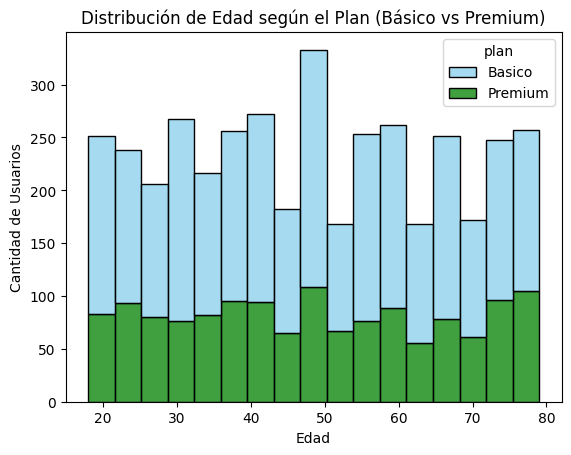

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan', multiple='stack', palette=['skyblue', 'green'],   edgecolor='black')

plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Edad según el Plan (Básico vs Premium)')
plt.show()

In [ ]:
user_profile.groupby('plan')['age'].mean()

plan
Basico     48.041618
Premium    48.310320
Name: age, dtype: float64

In [ ]:
jovenes = user_profile[user_profile['age'] < 35]
jovenes['plan'].value_counts(normalize=True) * 100

Basico     64.79638
Premium    35.20362
Name: plan, dtype: float64

💡Insights: el promedio de edad es igual en los dos planes por lo tanto no es un factor determinante para la elección del plan
- Distribución: La edad promedio es de 48 años, el rango de edad está entre 18 y 79 años, el 64.9 de los usuarios está en el plan Básico y 35.1 en plan Premium

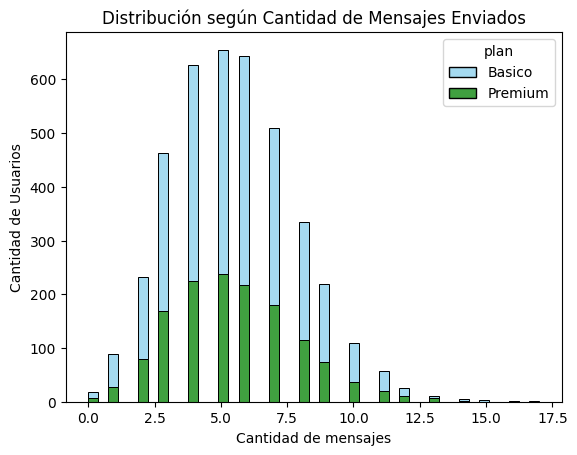

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan', multiple='stack', palette=['skyblue', 'green'],   edgecolor='black')

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución según Cantidad de Mensajes Enviados')
plt.show()

💡Insights: usuarios que tienen plan Básico tienden a enviar más mensajes que el Plan Premium (posiblemente porque el Plan Premium tiene incluidos más minutos para llamar)
- Distribución para la cantidad de mensajes tiende a dispersarce hacia la derecha.

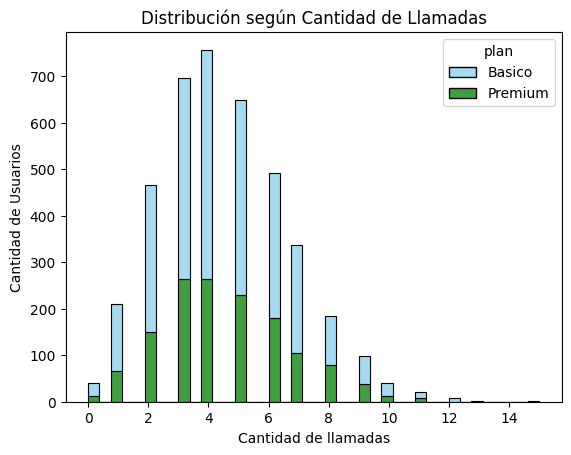

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan', multiple='stack', palette=['skyblue', 'green'], edgecolor='black')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución según Cantidad de Llamadas')
plt.show()

In [ ]:
user_profile.groupby('plan')['cant_llamadas'].mean()

plan
Basico     4.456438
Premium    4.518149
Name: cant_llamadas, dtype: float64

💡
Insights:El promedio de la cantidad de llamadas no hacen la diferencia para escoger el plan ya que practicamente es igual
- Distribución Presenta ligero sesgo a la derecha pero tiende a ser una distribución normal

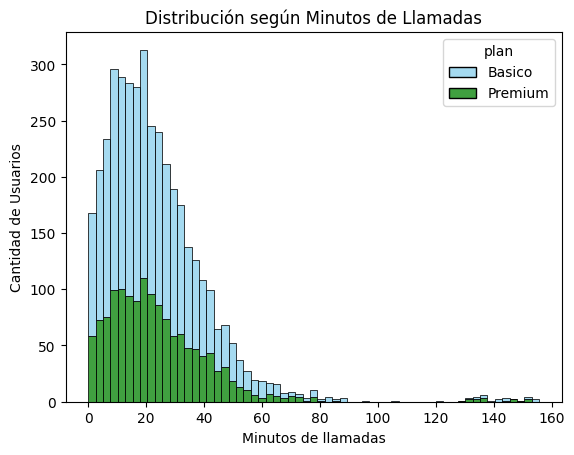

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan', multiple='stack', palette=['skyblue', 'green'], edgecolor='black')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución según Minutos de Llamadas')
plt.show()

In [ ]:
user_profile.groupby('plan')['cant_minutos_llamada'].mean()

plan
Basico     22.905436
Premium    24.077011
Name: cant_minutos_llamada, dtype: float64

💡Insights: la mayoría de los usuarios hacen llamadas cortas, de pocos minutos.
- Distribución: presenta un sesgo muy marcado a la derecha, más en el plan Premium que en el básico, debido seguramente a la cantidad de minutos que incluye el plan Premium, lo que hace determinante para escoger un plan, sin embargo una gran cantidad de usuarios Premium realizan llamadas cortas que les permitiría cambiar de plan y optimizar el costo del plan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

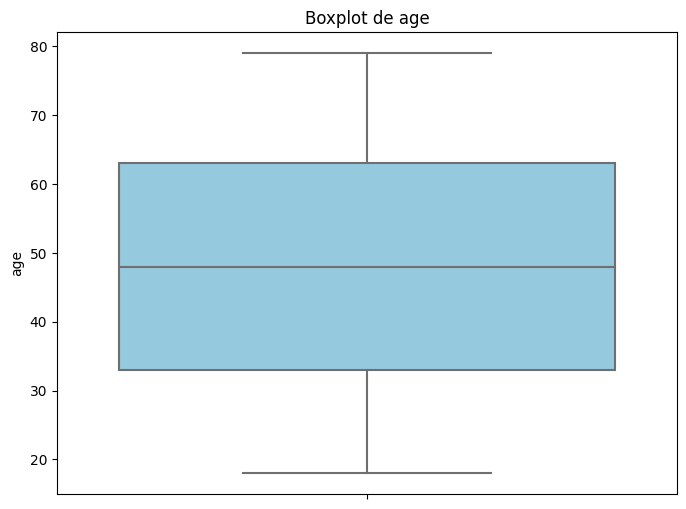

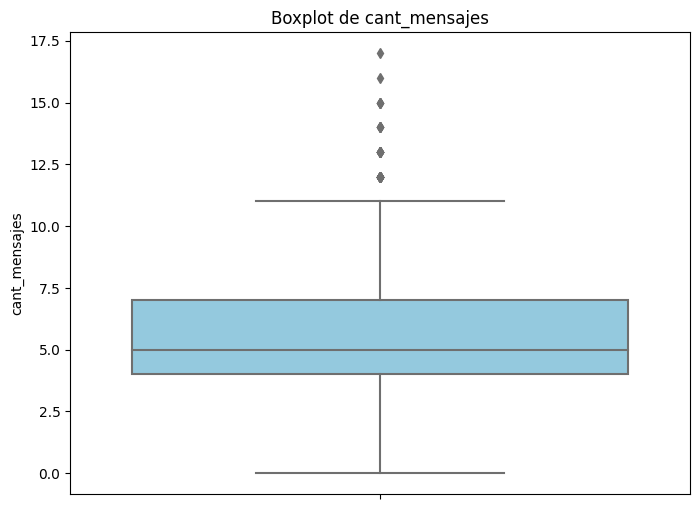

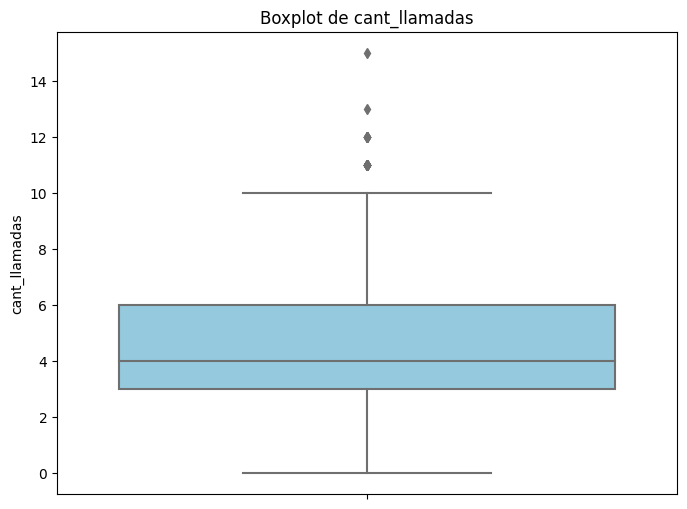

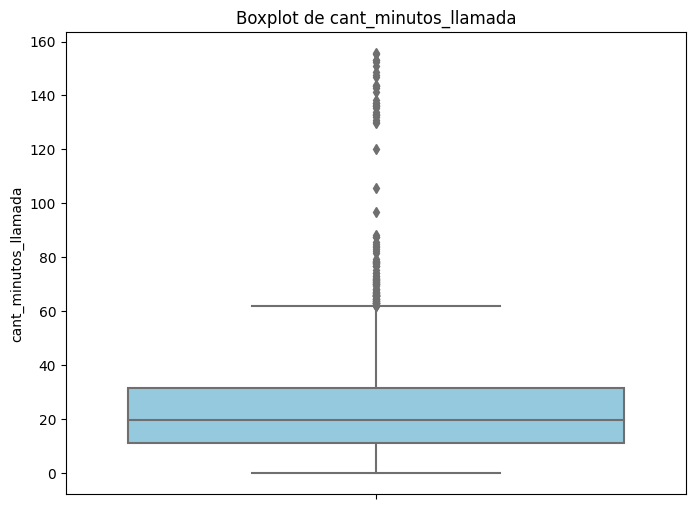

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()


💡Insights:
- Age: No presenta outliers, el rango de edad es normal, no tiene errores en su distribución.
- cant_mensajes: Tiene pocos outliers, que podrían no interferir con el analisis
- cant_llamadas: Igual que la cantidd de mensajes, tiene pocos outliers, que podrían no interferir con el analisis
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Calcular Q1, Q3, IQR
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular Q1, Q3, IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límites
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Contar outliers
    outliers_lower = (user_profile[col] < lower).sum()
    outliers_upper = (user_profile[col] > upper).sum()
    total_outliers = outliers_lower + outliers_upper

    # Mostrar resultados
    print(f'Columna: {col}')
    print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
    print(f'Límite inferior: {lower}')
    print(f'Límite superior: {upper}')
    print(f'Outliers inferiores: {outliers_lower}')
    print(f'Outliers superiores: {outliers_upper}')
    print(f'Total outliers: {total_outliers}')
    print('---')


Columna: cant_mensajes
Q1: 4.0, Q3: 7.0, IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5
Outliers inferiores: 0
Outliers superiores: 46
Total outliers: 46
---
Columna: cant_llamadas
Q1: 3.0, Q3: 6.0, IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5
Outliers inferiores: 0
Outliers superiores: 30
Total outliers: 30
---
Columna: cant_minutos_llamada
Q1: 11.12, Q3: 31.415, IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575
Outliers inferiores: 0
Outliers superiores: 109
Total outliers: 109
---


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.00,3999.00,3999.00
mean,5.52,4.48,23.32
std,2.36,2.14,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.12
50%,5.00,4.00,19.78
75%,7.00,6.00,31.42
max,17.00,15.00,155.69


💡Insights: las columnas de cantidad de mensajes y cantidad de llamadas presentan una desviación estándar baja mientras que la cantidad de minutos por llamada presenta una desviacion estándar muy alta para los datos
- cant_mensajes: mantener outliers, porqué pueden ser datos reales que vale la pena mantener y no presentan distorción de la información
- cant_llamadas: mantener outliers, porqué igual que cantidad de mensajes, mantener outliers, porqué pueden ser datos reales que vale la pena mantener y no presentan distorción de la información
- cant_minutos_llamada: no se deben mantener porque presenta una desviacion estandar muy alta, (hacia la derecha), y los valores tan altos se deben confirmar que no son errores y ajustarlos a la información para no distorcionarla.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso(row):
    call = row['cant_llamadas']
    sms = row['cant_mensajes']

    if call < 5 or sms < 5:
        return "Bajo uso"
    elif call < 10 or sms < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)
user_profile['grupo_uso'].value_counts()

Bajo uso     2819
Uso medio    1176
Alto uso        5
Name: grupo_uso, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Adulto,Bajo uso
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Adulto,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Adulto,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Bajo uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_volume(row):
    age = row['age']

    if age < 30:
        return "Joven"
    elif age < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

# aplicar función y verificar cambios
user_profile['grupo_edad'] = user_profile.apply(classify_volume, axis=1)
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

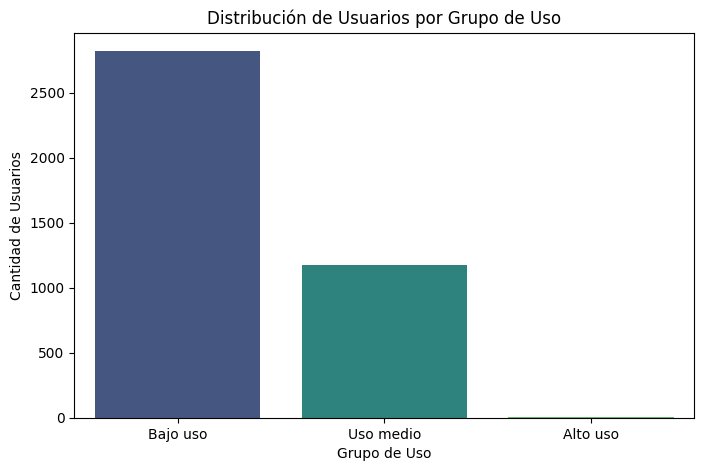

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

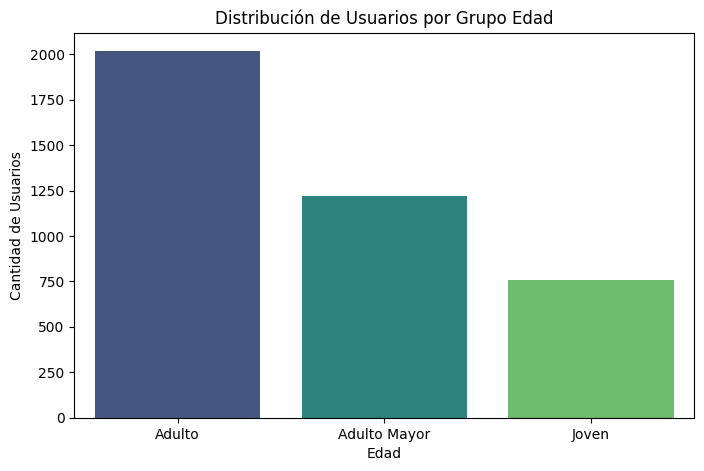

In [ ]:

# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='viridis')
plt.title('Distribución de Usuarios por Grupo Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


In [ ]:
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'], normalize='columns') * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,20.0,50.478893,50.510204
Adulto Mayor,40.0,30.436325,30.782313
Joven,40.0,19.084782,18.707483



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
      Los Datos completos: Sin valores nulos significativos.
      Estructura consistente: Los datasets tenían la estructura esperada.
      Outliers en segmentación: Los únicos problemas estaban en los rangos para crear grupos.
      No se eliminaron ni cambiaron datos ya que todos fueron válidos.
      Se mantuvo te la integridad de los datos originales.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    Los segmentos trabajados fueron: por edades: Adulto, Adulto Mayor y Joven
                                     por Uso : bajo uso, Medio uso y Alto uso

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    Los adultos con bajo y medio uso porque concentran el 50.47% y 50.51% respectivamente de los usuarios.

  - ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Los usuarios de alto costo ya generan ingresos significativos para la empresa y los usuarios de medio y bajo costo representan una oportunidad de crecimiento con ofertas estratégicas pueden ser la clave para hacer que estos usuarios migren a planes premium.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
INFORME EJECUTIVO – ANÁLISIS DE USUARIOS Y PATRONES DE USO
1. Calidad e Integridad de los Datos
El análisis inicial confirmó que los datasets presentaban una estructura sólida y sin problemas críticos, sin valores nulos significativos en columnas clave, estructura consistente entre los distintos archivos e integridad preservada: no fue necesario eliminar filas ni modificar datos originales.
El único hallazgo relevante fue la presencia de outliers en variables utilizadas para segmentación (edad y uso) que representan menos del 1% del total de filas y no requerían tratamiento para evitar la distorsión en los grupos.
2. Segmentación de Clientes
Para la segmentación, se construyeron dos grupos: por Edad (Joven, Adulto y Adulto Mayor) y por Segmentación por nivel de uso según las llamadas y los mensajes en (Bajo uso, Medio Uso y Alto uso)
•	Jóvenes → mayor actividad en mensajes.
•	Adultos → uso equilibrado entre llamadas y mensajes.
•	Adultos mayores → menor actividad general, predominio de bajo uso.

3. Segmentos más valiosos para ConnectaTel
El análisis muestra que los segmentos con mayor potencial estratégico son: Los adultos representan aproximadamente el 50% tanto del segmento de bajo uso como del medio uso, siendo el grupo etario más numeroso en ambas categorías, ya que son un grupo amplio, estable y con capacidad económica, que margen para incrementar consumo con incentivos adecuados y son ideales para campañas de activación, retención y migración a planes superiores.
•	Números específicos: Los adultos son 2,018 usuarios (50.45% del total)
•	Bajo uso: 2,819 usuarios (70.5% del total)
•	Medio uso: 1,176 usuarios (29.4% del total)

Usuarios de alto uso, ya generan ingresos significativos y que requieren mantener calidad del servicio y beneficios premium.
4. Patrones de Uso Extremo (Outliers)
Se identificaron dos comportamientos relevantes:
Los Usuarios de alto uso, consumen mucho más que el promedio, representan ingresos importantes y necesitan planes robustos y atención prioritaria.
Los Usuarios de bajo uso, pueden estar subutilizando el servicio, y representan una oportunidad de crecimiento mediante campañas de activación, beneficios adicionales y comunicación personalizada
5. Recomendaciones Estratégicas
Se sugiere: Optimizar la oferta de planes, aplicar estrategias de retención, efectuar comunicación segmentada para jóvenes, adultos y Adultos mayores y monitoreo continuo

Conclusión
El análisis permitió identificar segmentos clave, patrones de uso y oportunidades estratégicas.
Los adultos con bajo y medio uso representan el mayor potencial de crecimiento para ConnectaTel, mientras que los usuarios de alto uso requieren estrategias de fidelización.
La calidad de los datos fue adecuada, y la segmentación generada ofrece una base sólida para decisiones comerciales y futuras iniciativas analíticas.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- había algunos sentinels (-999) en la edad
- y 40 fechas futuras que se marcaron como nulas

🔍 **Segmentos por Edad**
- Adulto mayor
- Adulto
- Joven

📊 **Segmentos por Nivel de Uso**
- Alto uso
- Medio uso
- Bajo Uso

➡️ Esto sugiere que los adultos representan el segmento de mayor oportunidad estratégica porque:
Son el 50.45% del total de usuarios (2,018 personas)
Dominan tanto el segmento de bajo uso (50.47%) como medio uso (50.51%)
Tienen estabilidad económica y potencial de crecimiento en consumo
Representan una base sólida para estrategias de activación y retención
y los usuarios Premium no están maximizando los beneficios del plan
Hay una oportunidad de optimizar la propuesta de valor
Posible necesidad de reestructurar planes o crear opciones intermedias

💡 **Recomendaciones**
- Revisar los planes Premium para que más Adultos quieran obtenerlo
- Mantener promociones atractivas al segmentos de Adultos para que mantengan el servicio

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`